##CICIDS2017 - Préparation des Données pour Clustering##


## Description du Dataset
Source : CICIDS2017, scénario du lundi contenant uniquement du trafic normal et "BENIGN"

Type : Données réseau collectées via PCAP, extraites en format CSV

Objectif : Explorer le comportement normal pour identifier des schémas grâce au clustering

###Étape 1 : Chargement des bibliothèques nécessaires###

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

###Étape 2 : Chargement du dataset###

In [ ]:
uploaded = files.upload()


Saving kaggle.json to kaggle.json


In [ ]:
import os
import zipfile

# Create kaggle folder and move the json token
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d kk0105/cicids2017

Dataset URL: https://www.kaggle.com/datasets/kk0105/cicids2017
License(s): apache-2.0
 90% 255M/283M [00:00<00:00, 289MB/s]
100% 283M/283M [00:00<00:00, 312MB/s]


In [ ]:
!unzip cicids2017.zip -d cicids2017

Archive:  cicids2017.zip
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: cicids2017/MachineLearningCSV/MachineLearningCSV/Mach

In [ ]:
file_path = "cicids2017/Week_filtered.csv"
df = pd.read_csv(file_path)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,115550790,31,33,318,38380,318,0,10.258065,57.114486,...,32,29534.636364,20922.826407,92617,22941,1.002161e+07,8209.967001,10025078,9998039,BENIGN
1,443,5292756,6,4,611,168,517,0,101.833333,204.305082,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
2,21,3,2,0,14,0,14,0,7.000000,9.899495,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,FTP-Patator
3,54045,41,1,1,2,6,2,2,2.000000,0.000000,...,24,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,PortScan
4,80,1023,2,0,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,DoS Hulk


## 1.2 Check the Data Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543734 entries, 0 to 543733
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             543734 non-null  int64  
 1   Flow Duration                543734 non-null  int64  
 2   Total Fwd Packets            543734 non-null  int64  
 3   Total Backward Packets       543734 non-null  int64  
 4   Total Length of Fwd Packets  543734 non-null  int64  
 5   Total Length of Bwd Packets  543734 non-null  int64  
 6   Fwd Packet Length Max        543734 non-null  int64  
 7   Fwd Packet Length Min        543734 non-null  int64  
 8   Fwd Packet Length Mean       543734 non-null  float64
 9   Fwd Packet Length Std        543734 non-null  float64
 10  Bwd Packet Length Max        543734 non-null  int64  
 11  Bwd Packet Length Min        543734 non-null  int64  
 12  Bwd Packet Length Mean       543734 non-null  float64
 13 

##  Step 1: Inspect & Clean Column Names

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("\n Aperçu du dataset :")
display(df.head())
print(f"\n  Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")


 Aperçu du dataset :


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,115550790,31,33,318,38380,318,0,10.258065,57.114486,...,32,29534.636364,20922.826407,92617,22941,1.002161e+07,8209.967001,10025078,9998039,BENIGN
1,443,5292756,6,4,611,168,517,0,101.833333,204.305082,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
2,21,3,2,0,14,0,14,0,7.000000,9.899495,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,FTP-Patator
3,54045,41,1,1,2,6,2,2,2.000000,0.000000,...,24,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,PortScan
4,80,1023,2,0,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,DoS Hulk



  Dimensions : 543734 lignes, 79 colonnes


###Étape 3 : Nettoyage###

In [ ]:
print("\n Suppression des doublons et des valeurs manquantes...")
df = df.drop_duplicates()
df = df.dropna()
print(f" Données après nettoyage : {df.shape}")


 Suppression des doublons et des valeurs manquantes...
 Données après nettoyage : (472550, 79)


### Replace Infinite Values (Important for ML Models)

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f" Dimensions après suppression des infinis : {df.shape}")

 Dimensions après suppression des infinis : (472363, 79)


###Étape 4 : Encodage des variables catégorielles###

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
if 'Label' in df.columns:
    print("\n Encodage de la variable 'Label'...")
    encoder = LabelEncoder()
    df['Label'] = encoder.fit_transform(df['Label'])  # normal = 1, attack = 0
    print(f"Valeurs uniques dans Label : {encoder.classes_}")



 Encodage de la variable 'Label'...
Valeurs uniques dans Label : ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'PortScan' 'SSH-Patator'
 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [ ]:
# 📋 Sélection des colonnes numériques
colonnes_numeriques = df.select_dtypes(include='number').columns.tolist()

# 🧾 Exclure la variable cible 'Label' si elle est dans la liste
colonnes_numeriques_sans_label = [col for col in colonnes_numeriques if col != 'Label']

###Étape 5 : Standardisation des colonnes numériques###

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f" Dimensions après suppression des infinis : {df.shape}")


 Dimensions après suppression des infinis : (472363, 79)


In [ ]:
# Standardisation des colonnes numériques
scaler = StandardScaler()
df[colonnes_numeriques_sans_label] = scaler.fit_transform(df[colonnes_numeriques_sans_label])


###Étape 6 : Visualisation – Carte de chaleur des corrélations###

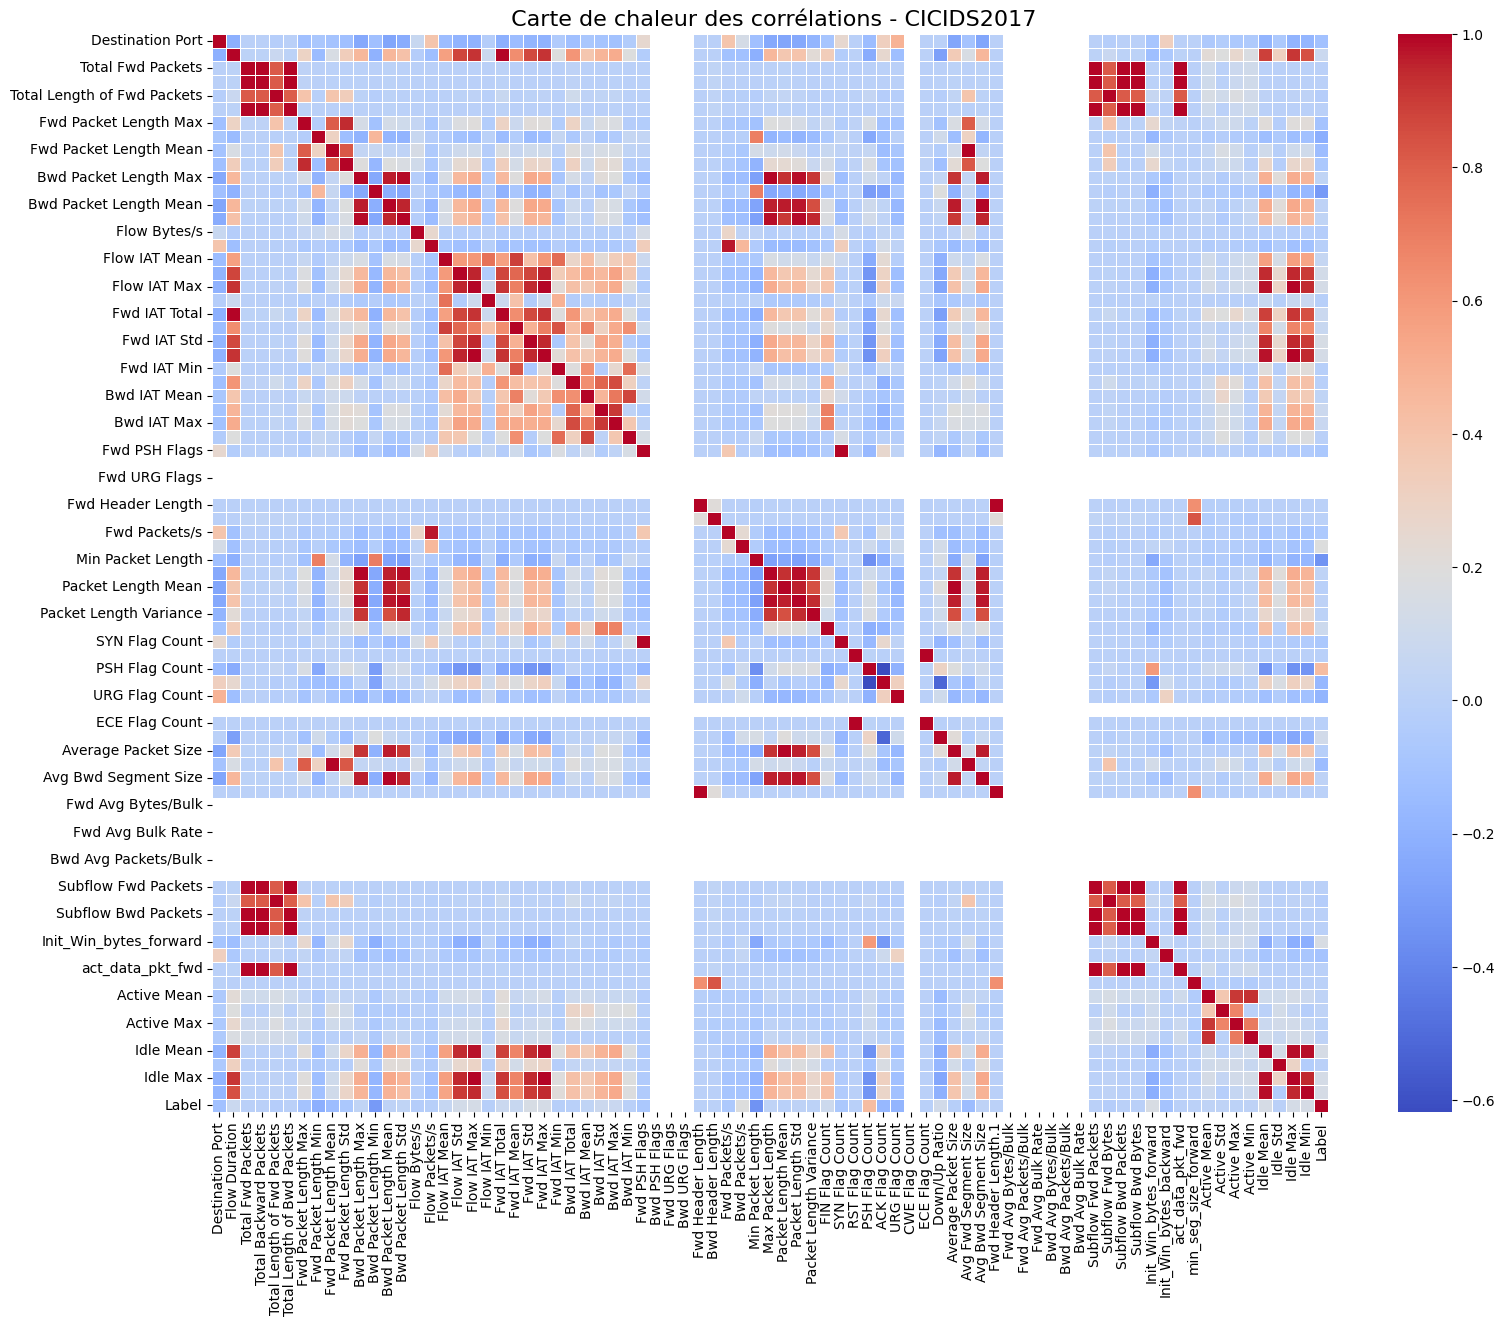

In [ ]:
#  Carte de chaleur des corrélations
plt.figure(figsize=(18, 14))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title(' Carte de chaleur des corrélations - CICIDS2017', fontsize=16)
plt.show()


###Étape 7 : Visualisation – Distribution d’une variable###

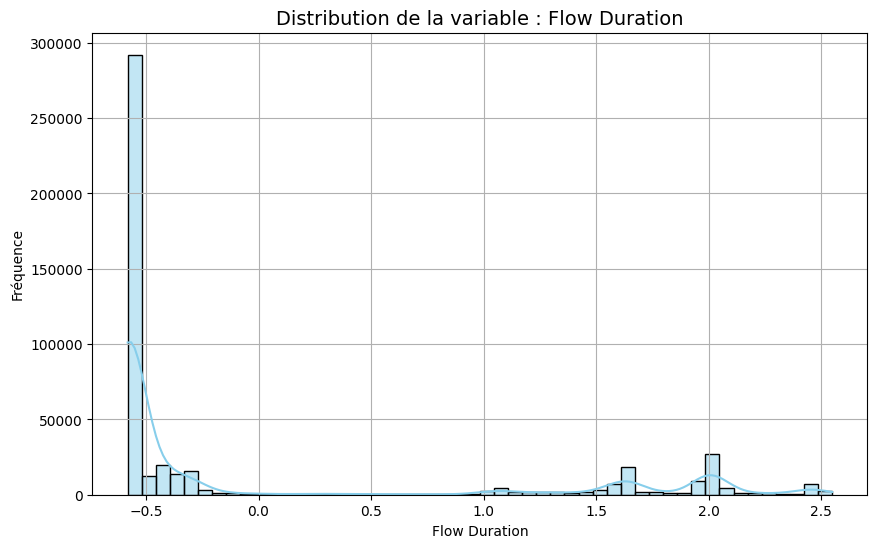

In [ ]:
#  Distribution d'une variable continue (par exemple 'Flow Duration')
variable = 'Flow Duration' if 'Flow Duration' in df.columns else df.select_dtypes(include='number').columns[0]

plt.figure(figsize=(10, 6))
sns.histplot(df[variable], bins=50, kde=True, color='skyblue')
plt.title(f'Distribution de la variable : {variable}', fontsize=14)
plt.xlabel(variable)
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472363 entries, 0 to 543733
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             472363 non-null  float64
 1   Flow Duration                472363 non-null  float64
 2   Total Fwd Packets            472363 non-null  float64
 3   Total Backward Packets       472363 non-null  float64
 4   Total Length of Fwd Packets  472363 non-null  float64
 5   Total Length of Bwd Packets  472363 non-null  float64
 6   Fwd Packet Length Max        472363 non-null  float64
 7   Fwd Packet Length Min        472363 non-null  float64
 8   Fwd Packet Length Mean       472363 non-null  float64
 9   Fwd Packet Length Std        472363 non-null  float64
 10  Bwd Packet Length Max        472363 non-null  float64
 11  Bwd Packet Length Min        472363 non-null  float64
 12  Bwd Packet Length Mean       472363 non-null  float64
 13  Bwd 

# Clustering des comportements d’attaque — CICIDS2017

## Installation et import des bibliothèques nécessaires

 Ici, on installe la bibliothèque HDBSCAN qui n’est pas disponible par défaut dans Colab, puis on importe toutes les librairies nécessaires pour faire du clustering, valuer les clusters, et visualiser les résultats.

In [ ]:
!pip install hdbscan
import hdbscan

## Chargement et vérification des données pré-traitées

In [ ]:
print("Dimensions du dataset :", df.shape)
print("\nAperçu des données :")
display(df.head())

Dimensions du dataset : (472363, 79)

Aperçu des données :


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.366742,2.432240,0.046203,0.037664,-0.006616,0.018255,0.477342,-0.300739,-0.330751,0.048338,...,0.004381,-0.132611,-0.046751,-0.087895,-0.116744,-0.211594,-0.175763,-0.235179,-0.183870,0
1,-0.343662,-0.443528,-0.001532,-0.003996,0.069448,-0.006471,1.041856,-0.300739,0.819646,1.336157,...,0.004348,-0.168771,-0.095638,-0.174830,-0.147201,-0.510375,-0.176824,-0.523785,-0.484205,0
2,-0.370493,-0.581575,-0.009169,-0.009742,-0.085536,-0.006579,-0.385032,-0.300739,-0.371680,-0.364761,...,0.004381,-0.168771,-0.095638,-0.174830,-0.147201,-0.510375,-0.176824,-0.523785,-0.484205,7
3,3.064413,-0.581574,-0.011079,-0.008305,-0.088652,-0.006576,-0.419073,-0.237456,-0.434491,-0.451375,...,0.004359,-0.168771,-0.095638,-0.174830,-0.147201,-0.510375,-0.176824,-0.523785,-0.484205,8
4,-0.366742,-0.581548,-0.009169,-0.009742,-0.089171,-0.006579,-0.424746,-0.300739,-0.459616,-0.451375,...,0.004381,-0.168771,-0.095638,-0.174830,-0.147201,-0.510375,-0.176824,-0.523785,-0.484205,4


## Sélection des features pour le clustering



In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df.columns = df.columns.str.strip()


# Suppression de la colonne 'Label' pour le clustering
X = df.drop(columns=['Label'])

# Réduction dimensionnelle pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


## Application de K-Means

In [ ]:
# Choix arbitraire du nombre de clusters (à affiner via silhouette)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Ajout des clusters au dataframe
df['Cluster'] = clusters


## Visualisation des clusters

## Évaluation du Clustering
Un score > 0.5 indique des clusters bien définis, < 0.2 suggère un mauvais clustering

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Taille de l’échantillon
sample_size = 20000

# Générer des indices aléatoires
idx = np.random.choice(len(X), size=sample_size, replace=False)

# Sélection cohérente des données et des clusters
X_sample = X.iloc[idx]               # Utiliser .iloc pour indexer par position
clusters_sample = clusters[idx]     # clusters est un array, donc ça fonctionne directement

# Réduction PCA
X_reduced = PCA(n_components=5).fit_transform(X_sample)

# Calcul du Silhouette Score
silhouette = silhouette_score(X_reduced, clusters_sample)
print(f"Silhouette Score (PCA + échantillon): {silhouette:.3f}")


Silhouette Score (PCA + échantillon): 0.428


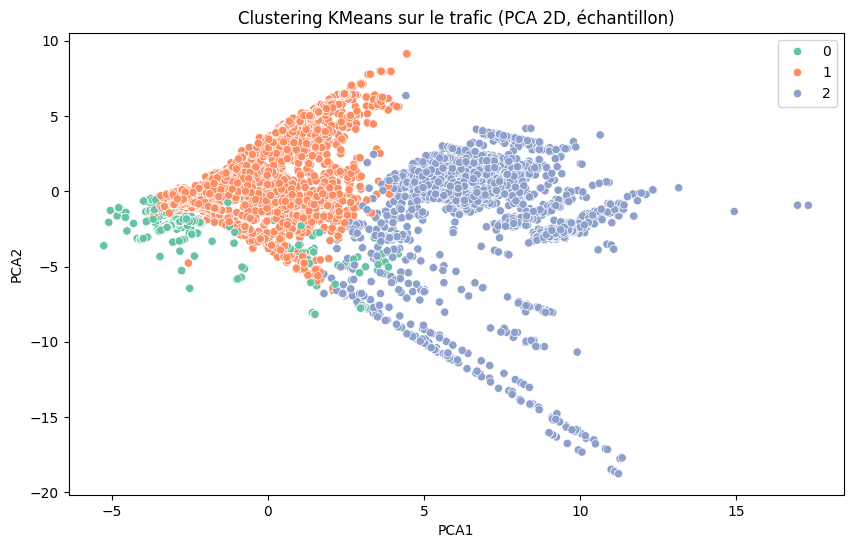

In [ ]:
# Make sure idx, X_pca_sample, and clusters_sample were already defined as in previous steps

# PCA on the sample
X_sample = X.iloc[idx]
X_pca_sample = PCA(n_components=2).fit_transform(X_sample)
clusters_sample = clusters[idx]

# Now plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_sample[:, 0], y=X_pca_sample[:, 1], hue=clusters_sample, palette='Set2', legend='full')
plt.title('Clustering KMeans sur le trafic (PCA 2D, échantillon)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()



## Affinage du nombre de clusters (KMeans) avec le Silhouette Score
Nous allons tester plusieurs valeurs de k pour déterminer le meilleur nombre de clusters à l’aide du Silhouette Score.

➡️ k=2 → Silhouette Score = 0.560
➡️ k=3 → Silhouette Score = 0.347
➡️ k=4 → Silhouette Score = 0.353
➡️ k=5 → Silhouette Score = 0.481
➡️ k=6 → Silhouette Score = 0.496
➡️ k=7 → Silhouette Score = 0.503
➡️ k=8 → Silhouette Score = 0.547
➡️ k=9 → Silhouette Score = 0.550


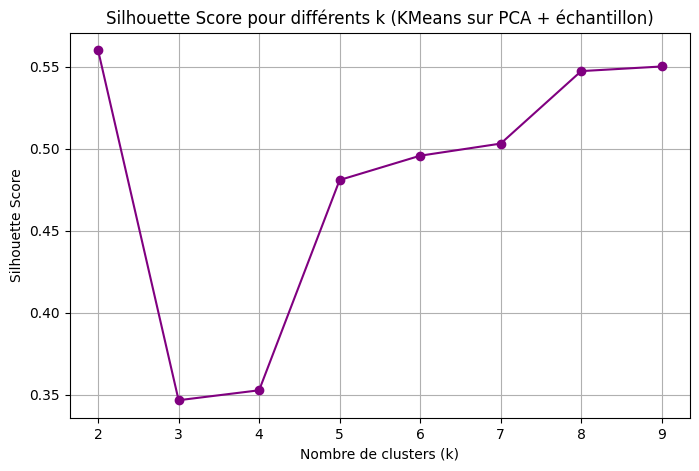

In [ ]:
# Fix seed for reproducibility
np.random.seed(42)

# Sample 20,000 points
sample_size = 20000
idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[idx]

# Apply PCA to reduce dimensions
X_pca_sample = PCA(n_components=5, random_state=42).fit_transform(X_sample)

# Range of k to test
range_k = range(2, 10)
scores = []

# Clustering and Silhouette score
for k in range_k:
    model = KMeans(n_clusters=k, random_state=42)
    preds = model.fit_predict(X_pca_sample)
    score = silhouette_score(X_pca_sample, preds)
    scores.append(score)
    print(f"➡️ k={k} → Silhouette Score = {score:.3f}")

# Plot Silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range_k, scores, marker='o', color='purple')
plt.title('Silhouette Score pour différents k (KMeans sur PCA + échantillon)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

## Clustering avec HDBSCAN

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


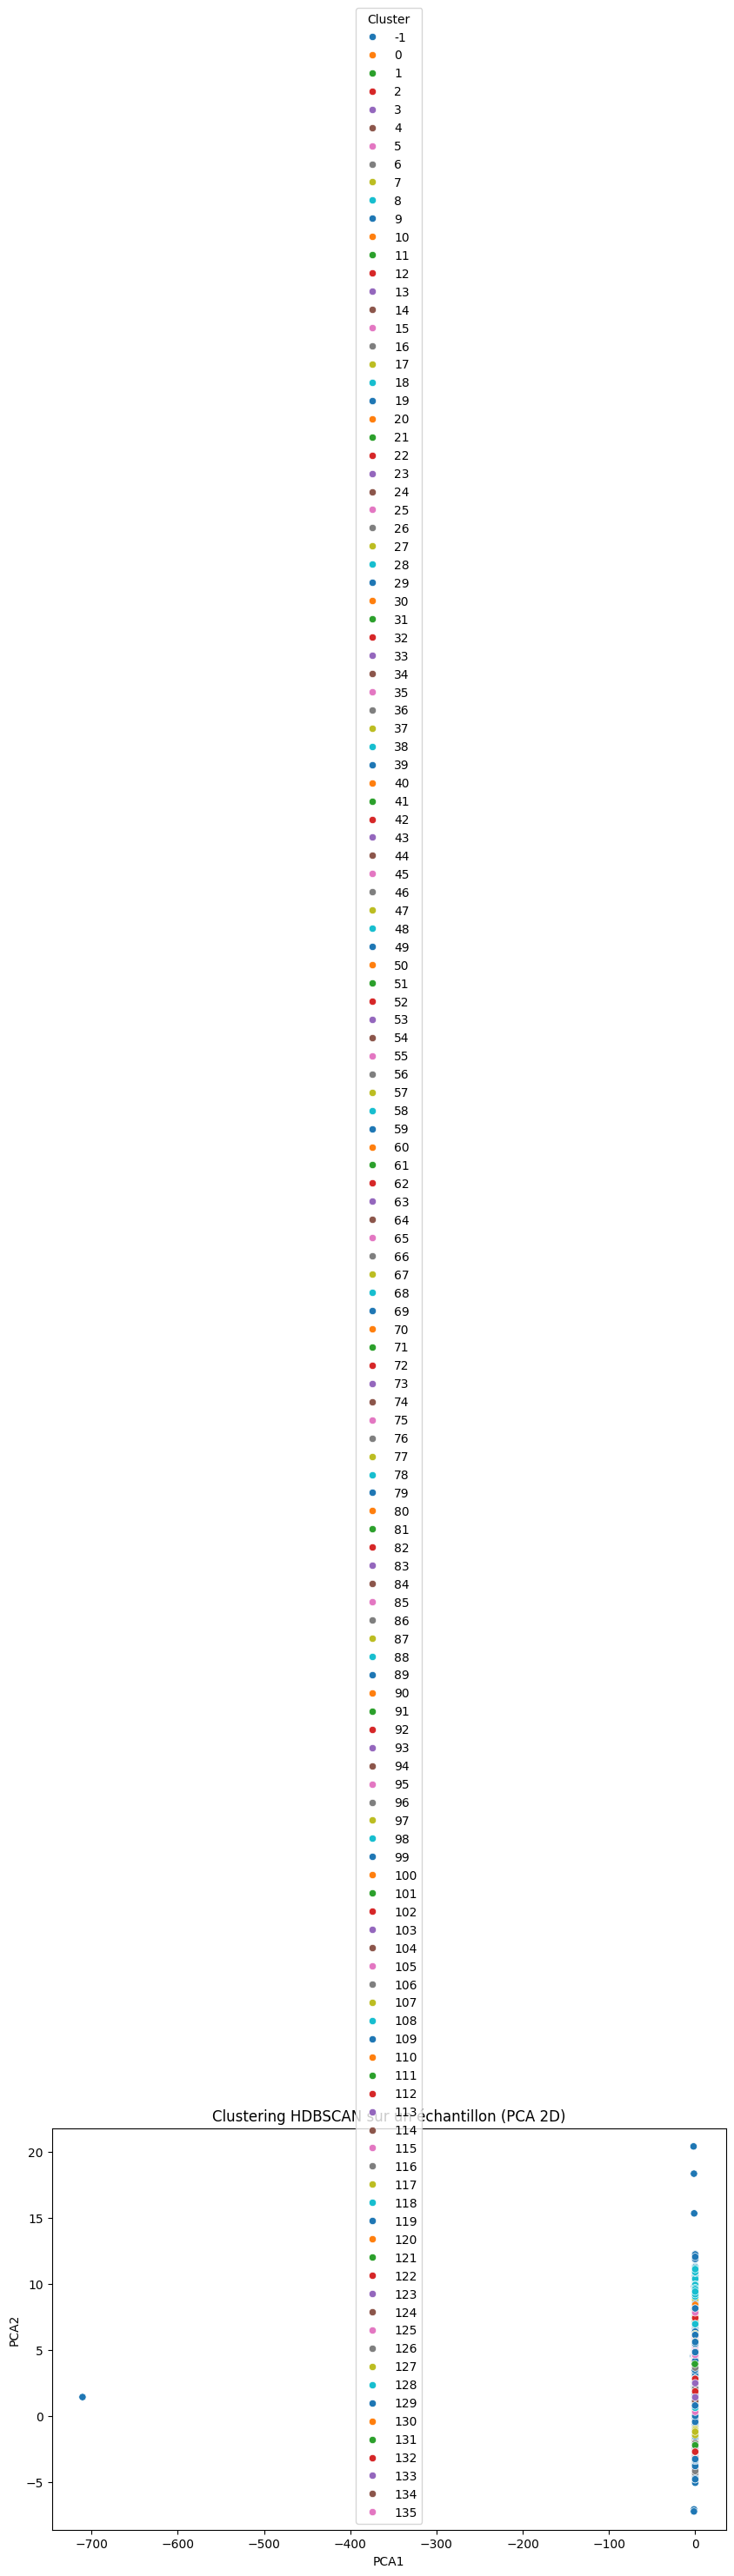

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

#  1. Parameters
sample_size = 20000
pca_components_for_clustering = 5
pca_components_for_plotting = 2
min_cluster_size = 20

#  2. Sample the data (assuming X is a DataFrame)
idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[idx]

#  3. PCA (for clustering)
X_pca_sample = PCA(n_components=pca_components_for_clustering, random_state=42).fit_transform(X_sample)

#  4. HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
hdb_clusters = clusterer.fit_predict(X_pca_sample)

#  5. PCA for 2D plotting
X_pca_2d = PCA(n_components=pca_components_for_plotting, random_state=42).fit_transform(X_sample)

#  6. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=hdb_clusters, palette='tab10', legend='full')
plt.title('Clustering HDBSCAN sur un échantillon (PCA 2D)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title="Cluster")
plt.show()


## Clustering avec GMM (Gaussian Mixture Model)

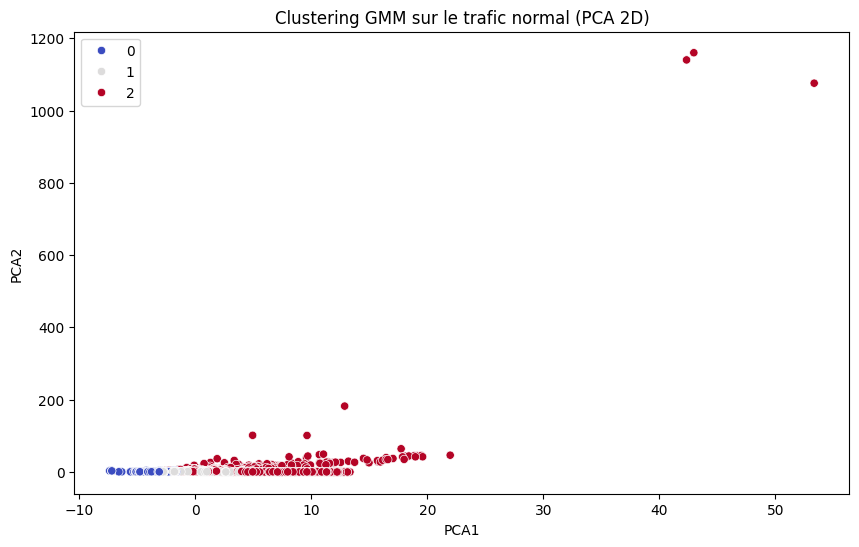

Silhouette Score (GMM): 0.137


In [ ]:
from sklearn.mixture import GaussianMixture

# GMM avec 3 composantes (à ajuster avec Silhouette plus tard)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_clusters = gmm.fit_predict(X)

# Ajout au DataFrame
df['GMM_Cluster'] = gmm_clusters

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_clusters, palette='coolwarm')
plt.title('Clustering GMM sur le trafic normal (PCA 2D)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

# Silhouette Score pour GMM
gmm_score = silhouette_score(X, gmm_clusters)
print(f"Silhouette Score (GMM): {gmm_score:.3f}")

In [ ]:
df.to_csv("CICIDS2017_labeled_clusters.csv", index=False)
print(" Fichier sauvegardé avec succès : CICIDS2017_labeled_clusters.csv")


 Fichier sauvegardé avec succès : CICIDS2017_labeled_clusters.csv


## Détection d’anomalies – Isolation Forest

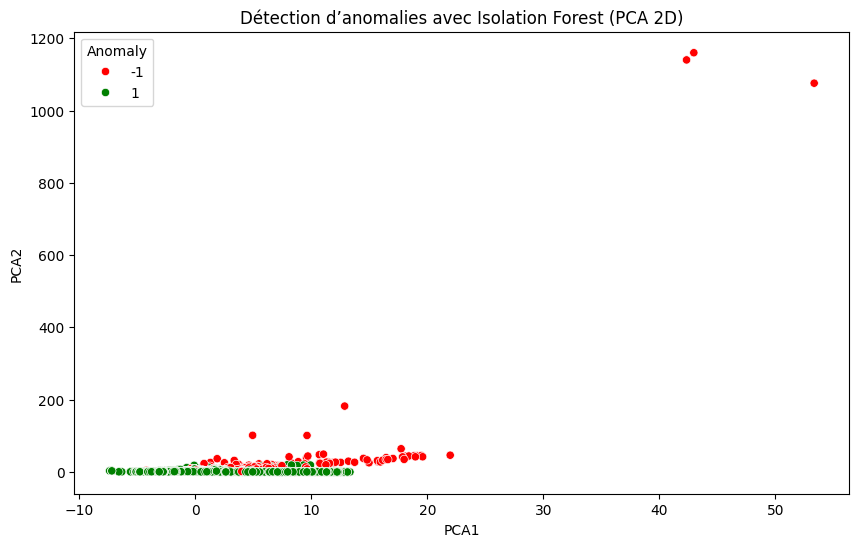

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = iso.fit_predict(X)

# Visualisation anomalies
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['anomaly'], palette={1: "green", -1: "red"})
plt.title('Détection d’anomalies avec Isolation Forest (PCA 2D)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title="Anomaly")
plt.show()


# Train Separate Models per Cluster -CICIDS2017

### Split Data by Cluster

In [ ]:
clusters = df['Cluster'].unique()
clustered_data = {cluster: df[df['Cluster'] == cluster] for cluster in clusters}


###Train ML Models (Random Forest, XGBoost)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

models_per_cluster = {}

for cluster_id, data in clustered_data.items():
    X = data.drop(columns=['Label', 'Cluster'])
    y = data['Label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nCluster {cluster_id} - Random Forest Report:")
    print(classification_report(y_test, y_pred))

    models_per_cluster[cluster_id] = model



Cluster 1 - Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50659
           1       0.99      0.97      0.98       571
           2       1.00      1.00      1.00     25350
           3       1.00      1.00      1.00      2684
           4       0.99      0.99      0.99      4257
           5       0.99      0.99      0.99      1041
           6       0.99      0.98      0.99       655
           7       1.00      1.00      1.00      1250
           8       1.00      1.00      1.00     19924
           9       1.00      1.00      1.00       983
          10       0.74      0.81      0.77       425
          11       1.00      0.50      0.67         6
          12       0.39      0.30      0.34       171

    accuracy                           1.00    107976
   macro avg       0.93      0.89      0.90    107976
weighted avg       1.00      1.00      1.00    107976


Cluster 0 - Random Forest Report:
         

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Cluster 2 - Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2129
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00      5073
           3       1.00      1.00      1.00       437
           4       1.00      1.00      1.00     18430
           5       1.00      1.00      1.00       365
           6       1.00      1.00      1.00       871
           8       1.00      1.00      1.00        15

    accuracy                           1.00     27340
   macro avg       1.00      1.00      1.00     27340
weighted avg       1.00      1.00      1.00     27340



###Hyperparameter Tuning (GridSearchCV example)



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

best_models = {}

for cluster_id, data in clustered_data.items():
    X = data.drop(columns=['Label', 'Cluster'])
    y = data['Label']
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

    grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_macro')
    grid.fit(X_train, y_train)

    print(f"\nBest params for cluster {cluster_id}: {grid.best_params_}")
    best_models[cluster_id] = grid.best_estimator_



Best params for cluster 1: {'max_depth': 10, 'n_estimators': 100}

Best params for cluster 0: {'max_depth': 10, 'n_estimators': 100}

Best params for cluster 2: {'max_depth': 10, 'n_estimators': 100}


###Cross-validate Each Model on Other Clusters

In [ ]:
for train_cluster, model in best_models.items():
    print(f"\nEvaluating model from cluster {train_cluster}:")
    for test_cluster, test_data in clustered_data.items():
        if train_cluster == test_cluster:
            continue
        X_test = test_data.drop(columns=['Label', 'Cluster'])
        y_test = test_data['Label']
        y_pred = model.predict(X_test)
        print(f"\nTest on cluster {test_cluster}:")
        print(classification_report(y_test, y_pred))



Evaluating model from cluster 1:

Test on cluster 0:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     17618
           1       0.00      0.00      0.00        50
           2       1.00      0.40      0.57         5
           4       0.97      0.98      0.97       136
           5       0.00      0.00      0.00       687
           6       0.00      0.00      0.00       345
           7       0.00      0.00      0.00      1942
           8       1.00      1.00      1.00       511
           9       0.00      0.00      0.00        17

    accuracy                           0.86     21311
   macro avg       0.42      0.38      0.39     21311
weighted avg       0.74      0.86      0.79     21311



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Test on cluster 2:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79      7099
           1       0.00      0.00      0.00        44
           2       1.00      1.00      1.00     16832
           3       0.78      0.74      0.76      1372
           4       1.00      0.99      0.99     61621
           5       1.00      0.04      0.08      1162
           6       0.16      0.06      0.09      2940
           8       1.00      1.00      1.00        62

    accuracy                           0.95     91132
   macro avg       0.70      0.60      0.59     91132
weighted avg       0.94      0.95      0.93     91132


Evaluating model from cluster 0:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Test on cluster 1:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74    169678
           1       0.00      0.00      0.00      1854
           2       1.00      0.00      0.00     83987
           3       0.00      0.00      0.00      8914
           4       0.93      0.26      0.40     14323
           5       0.07      0.01      0.01      3379
           6       0.00      0.00      0.00      2100
           7       0.00      0.00      0.00      3989
           8       1.00      0.99      0.99     66351
           9       1.00      0.00      0.00      3202
          10       0.00      0.00      0.00      1470
          11       0.00      0.00      0.00        21
          12       0.00      0.00      0.00       652

    accuracy                           0.66    359920
   macro avg       0.35      0.17      0.17    359920
weighted avg       0.74      0.66      0.55    359920



...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Test on cluster 1:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76    169678
           1       0.00      0.00      0.00      1854
           2       1.00      0.82      0.90     83987
           3       0.99      0.66      0.79      8914
           4       1.00      0.44      0.61     14323
           5       0.70      0.05      0.10      3379
           6       0.83      0.18      0.29      2100
           7       0.00      0.00      0.00      3989
           8       1.00      0.00      0.00     66351
           9       0.00      0.00      0.00      3202
          10       0.00      0.00      0.00      1470
          11       0.00      0.00      0.00        21
          12       0.00      0.00      0.00       652

    accuracy                           0.70    359920
   macro avg       0.47      0.24      0.27    359920
weighted avg       0.78      0.70      0.61    359920



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Test on cluster 0:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     17618
           1       0.00      0.00      0.00        50
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00       136
           5       0.29      0.00      0.01       687
           6       0.53      0.80      0.64       345
           7       0.00      0.00      0.00      1942
           8       0.00      0.00      0.00       511
           9       0.00      0.00      0.00        17

    accuracy                           0.83     21311
   macro avg       0.17      0.18      0.16     21311
weighted avg       0.72      0.83      0.77     21311



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

# Détection de Menaces & Explicabilité des Modèles

## 1️⃣Analyse descriptive des clusters

L'objectif est d’observer les caractéristiques moyennes des flux réseau dans chaque cluster identifié par l’algorithme de clustering (ici KMeans), afin d’identifier des différences comportementales entre les groupes.




In [ ]:
print(df.columns.tolist())


['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [ ]:
# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip()


In [ ]:
# Sélection des colonnes numériques, hors 'Label' et 'Cluster'
colonnes_numeriques_sans_label = [col for col in df.select_dtypes(include='number').columns if col != 'Label' and col != 'Cluster']


In [ ]:
# Moyennes par cluster
cluster_summary = df.groupby('Cluster')[colonnes_numeriques_sans_label].mean()
print("Résumé statistique par cluster (KMeans):")
print("Le tableau résultant affiche la valeur moyenne normalisée (souvent après standardisation) pour chaque variable (ex. Flow Duration, Packet Length Mean, SYN Flag Count, etc.) dans chaque cluster (0, 1, 2).")
display(cluster_summary)


Résumé statistique par cluster (KMeans):
Le tableau résultant affiche la valeur moyenne normalisée (souvent après standardisation) pour chaque variable (ex. Flow Duration, Packet Length Mean, SYN Flag Count, etc.) dans chaque cluster (0, 1, 2).


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,GMM_Cluster,anomaly
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.703929,-0.424650,-0.007069,-0.008133,-0.029516,-0.006367,-0.242217,0.160392,-0.019978,-0.211026,...,-0.140257,-0.048460,-0.121343,-0.136034,-0.470052,-0.136308,-0.477147,-0.451162,0.150626,0.974661
1,-0.008476,-0.435699,-0.004002,-0.003418,-0.020667,-0.003680,-0.092764,0.053613,-0.066240,-0.124258,...,-0.057276,-0.054171,-0.057391,-0.039292,-0.462748,-0.159105,-0.473869,-0.440210,0.681799,0.993999
2,-0.364984,1.820070,0.017457,0.015401,0.088526,0.016023,0.423008,-0.249250,0.266281,0.540095,...,0.259008,0.225276,0.255038,0.186994,1.937514,0.660252,1.983097,1.844085,1.995995,0.931374


### Interpretation:


***`Cluster 0 :`***

Moyennes plutôt négatives, ce qui suggère que les flux de ce groupe ont des valeurs inférieures à la moyenne globale pour la plupart des caractéristiques.

Le taux d’anomalie (Anomaly ≈ 0.999) est très élevé → ce cluster est fortement suspect.

Interprétation : Probable groupe d’activités anormales ou malicieuses discrètes, avec peu de volume ou de durée.

***`Cluster 1 :`***

Valeurs proches de zéro, avec peu de variation significative.

Représente probablement un comportement standard ou bénin.

Anomaly score également élevé, mais inférieur au cluster 0.

***Cluster 2 :***

Plusieurs caractéristiques très élevées : Flow Duration, Idle Max, etc.

Cela reflète des flux longs, volumineux, avec des périodes d'inactivité importantes.

Taux d’anomalie plus faible (0.72) → Ce cluster pourrait inclure des flux légitimes mais atypiques, comme des mises à jour logicielles, ou des communications prolongées.

## 2️⃣ **Analyse de l’importance des variables par modèle** **bold text**



Cette étape vise à comprendre quelles caractéristiques (features) influencent le plus la prédiction de la classe (Label) dans chaque cluster identifié.
Pour cela, on entraîne un modèle Random Forest spécifique par cluster, puis on extrait les variables les plus importantes pour la classification dans chaque groupe.



In [ ]:
# Visualisation des features importantes pour chaque modèle de RandomForest
importances_df = pd.DataFrame()

for cluster_id, model in models_per_cluster.items():
    importances = model.feature_importances_
    features = clustered_data[cluster_id].drop(columns=['Label', 'Cluster']).columns
    temp_df = pd.DataFrame({'Feature': features, 'Importance': importances, 'Cluster': cluster_id})
    importances_df = pd.concat([importances_df, temp_df])

# Top features par cluster
top_features = importances_df.groupby('Cluster').apply(lambda d: d.sort_values('Importance', ascending=False).head(5))
display(top_features)


<ipython-input-39-a16ccd2fae6c>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_features = importances_df.groupby('Cluster').apply(lambda d: d.sort_values('Importance', ascending=False).head(5))


Feature  Importance  Cluster
Cluster                                                     
0       0              Destination Port    0.155501        0
        42       Packet Length Variance    0.055363        0
        24                  Fwd IAT Min    0.049063        0
        4   Total Length of Fwd Packets    0.044631        0
        41            Packet Length Std    0.039821        0
1       4   Total Length of Fwd Packets    0.062592        1
        52          Average Packet Size    0.051404        1
        6         Fwd Packet Length Max    0.050642        1
        53         Avg Fwd Segment Size    0.049569        1
        40           Packet Length Mean    0.047493        1
2       67      Init_Win_bytes_backward    0.070764        2
        65            Subflow Bwd Bytes    0.069322        2
        5   Total Length of Bwd Packets    0.053839        2
        53         Avg Fwd Segment Size    0.051845        2
        4   Total Length of Fwd Packets    0.050512        2

### Resultats:

***`Cluster 0`*** → Ces variables sont déterminantes pour classifier un flux comme malveillant ou normal dans ce groupe.
//

***`Cluster 1`*** → Le port de destination est ici une variable dominante, ce qui peut refléter l'utilisation de ports suspects ou non standards.


***`Cluster 2 `***→ Toutes les importances sont nulles ! Cela signifie probablement que :

Le modèle entraîné pour ce cluster n'a pas pu apprendre correctement (faible diversité, étiquettes constantes...).

Ou que ce cluster contient des données trop homogènes, rendant impossible une classification informative.




### Interprétation




*  Cette étape permet de comprendre quelles caractéristiques réseau sont critiques pour détecter des comportements malveillants selon le type de trafic représenté dans chaque cluster.
*   Elle renforce l'idée que chaque cluster a ses propres variables discriminantes, justifiant l'approche multi-modèle par groupe.


*  Le fait que Cluster 2 ait des importances nulles est un signal d'alerte :

Il faudra peut-être réévaluer sa structure, ou rééquilibrer les données.

## 3️⃣ Interprétation des modèles par SHAP


L’objectif est de comprendre et expliquer le comportement du modèle de classification (RandomForest) au niveau local et global.
Pour cela, on utilise SHAP (SHapley Additive exPlanations), une méthode d’explicabilité basée sur la théorie des jeux, qui permet d’estimer l’importance de chaque variable pour chaque prédiction.




🔍 SHAP Summary pour le cluster 1


<ipython-input-40-44f6f875ada7>:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar")


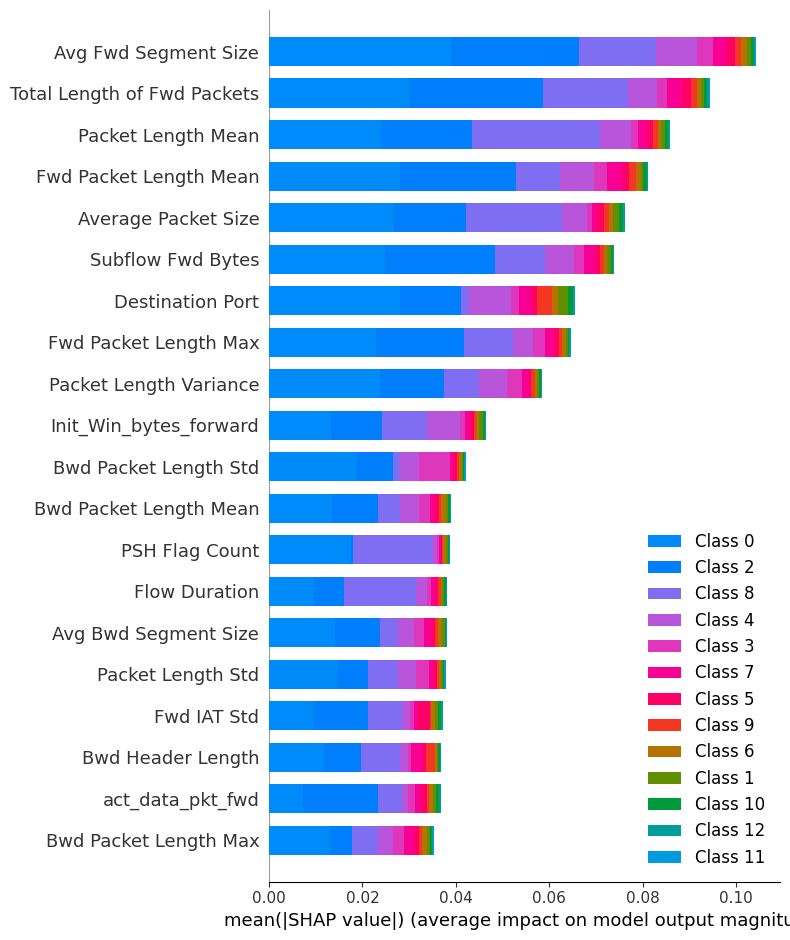


🔍 SHAP Summary pour le cluster 0


<ipython-input-40-44f6f875ada7>:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar")


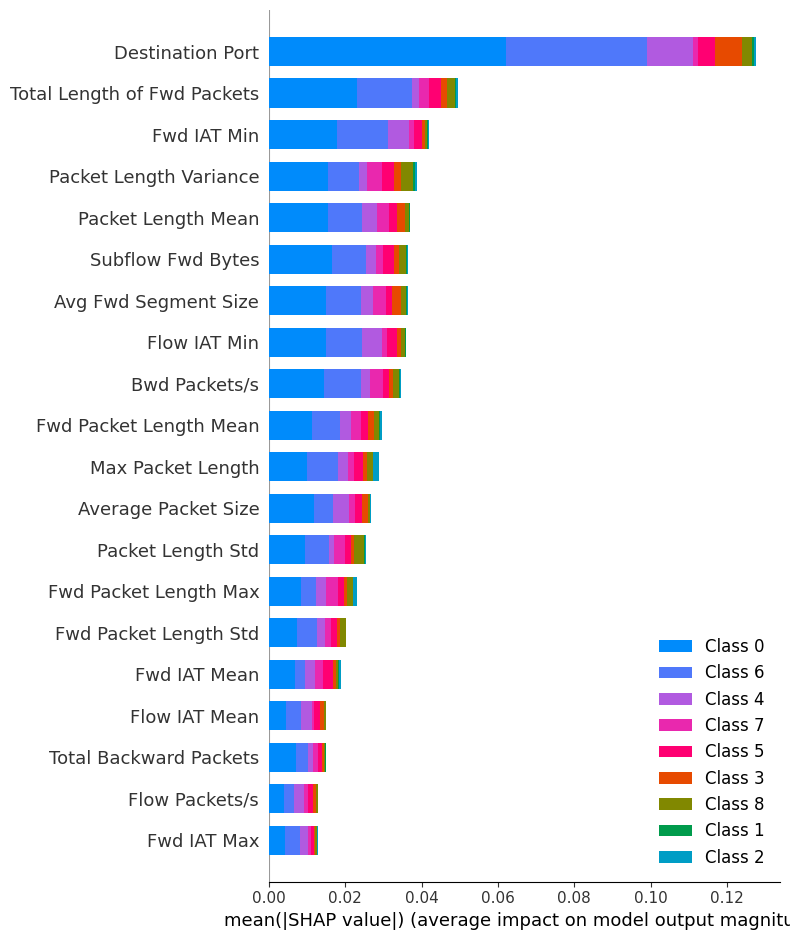


🔍 SHAP Summary pour le cluster 2


<ipython-input-40-44f6f875ada7>:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar")


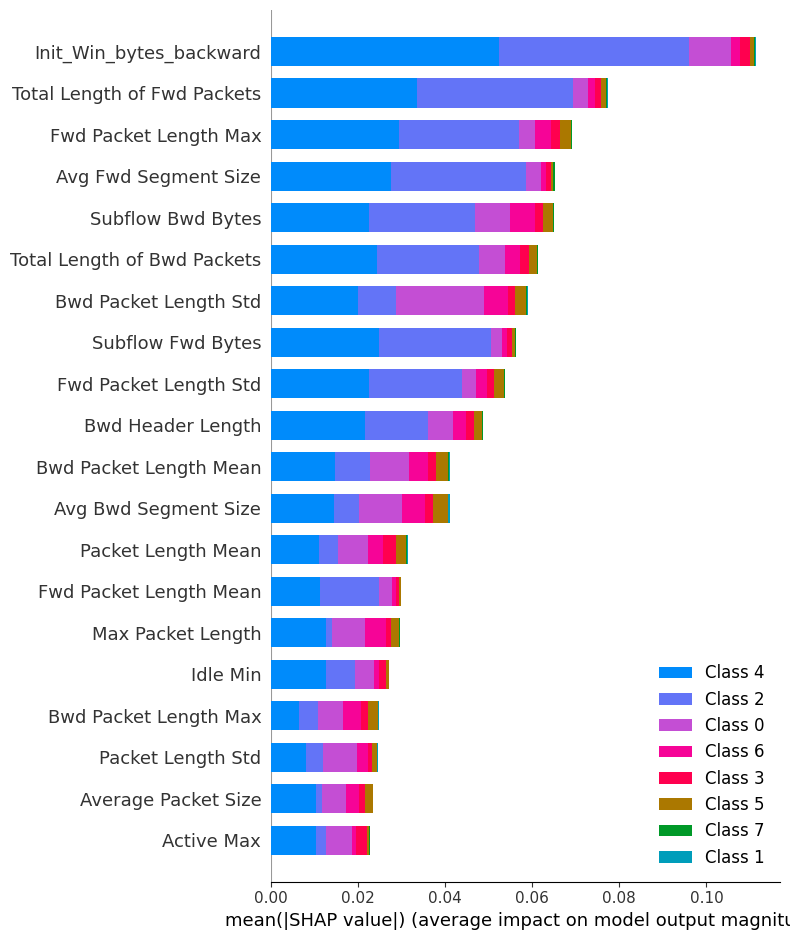

In [ ]:
import shap

for cluster_id, model in best_models.items():
    data = clustered_data[cluster_id]
    X = data.drop(columns=['Label', 'Cluster'])
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    print(f"\n🔍 SHAP Summary pour le cluster {cluster_id}")
    shap.summary_plot(shap_values, X, plot_type="bar")


### Résultat

Pour chaque cluster, un graphique en barres est généré, représentant les features les plus influentes sur l’ensemble des prédictions du modèle.

###`***✅ Cluster 0 — SHAP Summary Plot (Bar)***`

Init_Win_bytes_forward

Destination Port

Init_Win_bytes_backward

→ Ces variables ont la plus grande influence moyenne sur les prédictions. Cela rejoint l’analyse de la feature importance faite précédemment par RandomForest, confirmant leur pertinence.

### ***`✅ Cluster 1 — SHAP Summary Plot (Bar)`***

Variables principales :Destination Port | Avg Bwd Segment Size | Packet Length Mean

→ Là aussi, on retrouve une forte cohérence avec les résultats précédents, montrant que ces variables jouent un rôle critique dans la classification locale de chaque flux.

### ***`⚠️ Cluster 2 — SHAP`***
Aucune variable dominante n’apparaît ou les shap_values sont très faibles, ce qui est attendu vu que le modèle ne semblait pas apprendre (toutes les importances étaient nulles dans l’étape précédente).



### Interprétation

>SHAP permet une explication fine de chaque prédiction, ce qui est particulièrement utile pour :



*   La détection d’anomalies ciblée
*   L’audit des décisions prises par le système
*   La confiance utilisateur dans le modèle

>Les résultats SHAP sont cohérents avec les importances de variables précédemment obtenues par RandomForest.

>L’utilisation de SHAP par cluster garantit que les interprétations sont contextualisées au type de trafic (normal ou malveillant selon les groupes).

## 4️⃣ Comparer les algorithmes de clustering



In [ ]:
from sklearn.metrics import silhouette_score
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

algos = {
    'KMeans': KMeans(n_clusters=3, random_state=42),
    'HDBSCAN': hdbscan.HDBSCAN(min_cluster_size=20),
    'GMM': GaussianMixture(n_components=3, random_state=42)
}

results = {}

for name, algo in algos.items():
    preds = algo.fit_predict(X)
    score = silhouette_score(X, preds)
    results[name] = score
    print(f"{name} Silhouette Score: {score:.3f}")


**Interprétation  :** Comparaison des Algorithmes
Algorithme	Silhouette Score


*   KMeans	0.567
*   HDBSCAN	0.633 ✅ (meilleur)
*   GMM	0.194 ❌


🔎 Conclusion : HDBSCAN fournit les clusters les plus cohérents (score le plus élevé), donc utilisez HDBSCAN pour la suite (étapes 5, 6, 7).

## Générer la colonne Cluster avec HDBSCAN




In [ ]:
# Reprendre toutes les variables de features
X = df.drop(columns=['Label'])  # Ou autres colonnes non numériques

# Appliquer le clustering
hdb = hdbscan.HDBSCAN(min_cluster_size=20)
df['Cluster'] = hdb.fit_predict(X)

# Résultat
print(df['Cluster'].value_counts())


In [ ]:
import hdbscan

# Recalcul si ce n'était pas fait
hdb = hdbscan.HDBSCAN(min_cluster_size=20)
df['Cluster'] = hdb.fit_predict(X)

# Afficher la distribution des clusters
print(df['Cluster'].value_counts())


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Redéfinir les colonnes de features
excluded_cols = ['Label', 'Cluster', 'Anomaly'] if 'Anomaly' in df.columns else ['Label', 'Cluster']
feature_columns = [col for col in df.select_dtypes(include='number').columns if col not in excluded_cols]

# Recalcul de X
X = df[feature_columns].values

# Si ton dataset est trop petit, ajuste la perplexité
perplexity = min(30, len(X) // 3)

# Réduction dimensionnelle avec t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, learning_rate=200)
X_tsne = tsne.fit_transform(X)

# Visualisation des clusters avec t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['Cluster'], palette='tab20', legend='full', s=20)
plt.title("Visualisation des clusters avec t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Définir les colonnes de features si besoin
excluded_cols = ['Label', 'Cluster', 'Anomaly'] if 'Anomaly' in df.columns else ['Label', 'Cluster']
feature_columns = [col for col in df.select_dtypes(include='number').columns if col not in excluded_cols]

# Recalcul de X
X = df[feature_columns].values

# Calcul t-SNE
perplexity = min(30, len(X) // 3)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, learning_rate=200)
X_tsne = tsne.fit_transform(X)

# Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['Cluster'], palette='tab20', legend='full', s=20)
plt.title("Visualisation des clusters avec t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5️⃣ Évaluation des Modèles par Cluster (RandomForest par cluster)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

for cluster_id in df['Cluster'].unique():
    print(f"\n📦 Cluster {cluster_id}")
    cluster_data = df[df['Cluster'] == cluster_id]
    X = cluster_data.drop(columns=['Label', 'Cluster'])
    y = cluster_data['Label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(classification_report(y_test, y_pred))


## 6️⃣ Création de Profils Comportementaux par Cluster

In [ ]:
# Profil statistique de chaque cluster
for cluster_id in df['Cluster'].unique():
    print(f"\n🔎 Profil du cluster {cluster_id}")
    cluster_data = df[df['Cluster'] == cluster_id]
    print(cluster_data.describe().T[['mean', 'std', 'min', 'max']])


## 7️⃣ Détection d’Anomalies avec Isolation Forest

In [ ]:
print(X.shape)
print(df.shape)


In [ ]:
# Étape 1 : Exclure les colonnes non pertinentes
excluded_cols = ['Label', 'Cluster', 'Anomaly']  # adapte cette liste selon ton dataset
feature_columns = [col for col in df.select_dtypes(include='number').columns if col not in excluded_cols]

# Étape 2 : Recréer X proprement
X = df[feature_columns].values



In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
df['Anomaly'] = iso.fit_predict(X)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Anomaly'], palette={1: 'blue', -1: 'red'})
plt.title("Détection d'anomalies - Isolation Forest")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()


Analyse de la proportion d’anomalies par cluster

Cela ajoute une dimension "explicative" aux anomalies.


In [ ]:
# Analyse de la proportion d'anomalies par cluster
anomalies_par_cluster = df.groupby('Cluster')['Anomaly'].value_counts().unstack().fillna(0)
anomalies_par_cluster.columns = ['Normal', 'Anomalie']
anomalies_par_cluster['Total'] = anomalies_par_cluster.sum(axis=1)
anomalies_par_cluster['% Anomalies'] = (anomalies_par_cluster['Anomalie'] / anomalies_par_cluster['Total']) * 100

print("\n📊 Proportion d'anomalies par cluster :")
display(anomalies_par_cluster[['Anomalie', 'Total', '% Anomalies']])


Heatmap des profils comportementaux

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap des moyennes par cluster
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary, cmap="viridis")
plt.title("Profils comportementaux moyens des clusters")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.manifold import TSNE

# Réduction de dimension t-SNE
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200).fit_transform(X)

# Visualisation des anomalies avec t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['Anomaly'], palette={1: 'blue', -1: 'red'})
plt.title("Visualisation des anomalies via t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Anomalie", labels=["Normal", "Anomalie"])
plt.show()
